# Desafio

A empresa Você Mais Seguro fornece planos de saúde e seguros de vida. 
A empresa está interessada em lança um novo seguro de veiculos, e desja entender a propensão de compra de seus clientes para este novo cenário. 
Em uma primeira etapa, foi realizada uma grande pesquisa com seus cleintes, para entender quais destes clientes estariam interessados em adquirir o novo seguro de veiculos.

Agora, com novos clientes do plano de saude entrando para sua base, a empresa deseja entender quais destes novos clientes teriam maior propensão de compra do novo seguro de veiculos.
No entanto, a empresa não esta interessada em gastar com pesquisas para todos os novos clientes, e sim apenas para aqueles que tem maior propensão de compra, 
haja visto,que seu efetivo comercial, não é capaz de entrar em contato, para fornecer um processo de pré vendas personalizado para toda a base de seus novos clientes, somente
para 2000 deles de cada vez. 

Para isso, este projeto tem como objetivo apresentar uma lista, com os 2000 clientes com maior probabilidade de venda do seguro de veículos.

# 0.0 Imports

In [79]:
import os
import json

import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np 
import seaborn as sns

from sklearn.linear_model   import LogisticRegression
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.tree           import DecisionTreeClassifier 
from sklearn.svm            import SVC 
from sklearn.ensemble       import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from xgboost                import XGBClassifier 
from sklearn import metrics as mt 


from torch import nn 
import torch.nn.functional as F
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm 


### 0.1 Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 8]
    plt.rcParams['font.size'] = 24
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    sns.set()

jupyter_settings()

def print_descriptive_stats(df,
                            column):
    print(f'**Clientes que adquiririam o Seguro - {column} statistics**')
    print(df[df.Response == 1][column].describe())
    print('-'*45)
    print(f'**Clientes NAO que adquiririam o Seguro - {column} statistics**')
    print(df[df.Response == 0][column].describe())
    print('\n')

def get_frequency_table(df, column): 

    df_frequency_1 = df[df.Response == 1].groupby(column).Response.count().reset_index()
    df_frequency_1.rename(columns={'Response':'Count_Response_1'}, inplace=True)


    df_frequency_0 = df[df.Response == 0].groupby(column).Response.count().reset_index()
    df_frequency_0.rename(columns={'Response':'Count_Response_0'}, inplace=True)

    df_frequency = pd.merge(df_frequency_1, df_frequency_0, on=column, how='inner') 
    df_frequency['Total'] = df_frequency['Count_Response_1'] + df_frequency['Count_Response_0']
    df_frequency['Propensity_to_buy'] = df_frequency['Count_Response_1']/df_frequency['Total']
    df_frequency['%_sample_to_buy'] = df_frequency['Count_Response_1']/df_frequency['Count_Response_1'].sum() 
    df_frequency['%_sample_to_not_buy'] = df_frequency['Count_Response_0']/df_frequency['Count_Response_0'].sum() 
    df_frequency['%_sample_size']   = df_frequency['Total']/len(df)
    df_frequency['%_general_propensity_to_buy'] = len(df[df.Response==1])/len(df)
    
    return df_frequency

def transform_pipeline(df):

    '''
    [EM FASE DE VALIDACAO....]
    '''
    from sklearn.preprocessing import StandardScaler, MinMaxScaler 


    region_code = df.Region_Code.copy()
    dummies_region_code = pd.get_dummies(region_code,prefix = "region_code")

    sales_channel = df.Policy_Sales_Channel.copy()
    dummies_sales_channel = pd.get_dummies(sales_channel,prefix = "policy_sales_channel")

    df_copy = df.copy()
    df_encoded = pd.concat([df_copy, dummies_sales_channel, dummies_region_code], axis = 1)

    df_encoded.loc[:,'Vehicle_Age'] = df_encoded.loc[:,'Vehicle_Age'].map({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2})


    df_encoded.drop(columns = ['Region_Code','Policy_Sales_Channel'], inplace = True)

    map_sexo_feminino = {
        'Male' : 0,
        'Female' : 1 
    }

    df_encoded['sexo_feminino'] = df_encoded.Gender.map(map_sexo_feminino)


    df_encoded.Vehicle_Damage = df_encoded.Vehicle_Damage.map({
        'Yes' : 1,
        'No'  : 0
    })


    scaller_premium      = MinMaxScaler()
    scaller_vintage      = MinMaxScaler()
    scaller_age          = MinMaxScaler()
    scaller_faixa_etaria = MinMaxScaler()

    df_encoded.Vintage_Scalled        = scaller_vintage.fit_transform(df_encoded.Vintage.values.reshape(-1,1))
    df_encoded.Annual_Premium_Scalled = scaller_premium.fit_transform(df_encoded.Annual_Premium.values.reshape(-1,1))


    df_encoded.Age        = scaller_age.fit_transform(df_encoded.Age.values.reshape(-1,1))
    df_encoded.faixa_etaria        = scaller_faixa_etaria.fit_transform(df_encoded.faixa_etaria.values.reshape(-1,1))


    df_encoded.Annual_Premium.describe()

    df_to_model = df_encoded[[x for x in df_encoded.columns if x not in ['id','Vintage_months','Vintage_weeks','Vintage']]]

    return df_to_model

def precision_top_k(top_k : int, 
                    y_true : np.array, 
                    y_proba : np.array):
    '''
    args:
        top_k: top_k elements to compute precision score
        y_true: true lables of y set 
        y_proba: estimated probabilities for y taking from some model 

    returns:
        precision : float - precision score. 
    '''
    evaluations = pd.DataFrame(y_true, 
                               columns = ['y_true'])
    evaluations['y_proba'] = y_proba
  
    evaluations = evaluations.sort_values(by = 'y_proba', ascending=False).reset_index(drop = True)
    evaluations = evaluations.iloc[:top_k]
    
    precision = evaluations.y_true.sum()/len(evaluations)

    return precision 

def recall_top_k(
        top_k : float,
        y_true : np.array, 
        y_proba : np.array
):
    
    evaluations = pd.DataFrame(y_true, 
                               columns = ['y_true'])
    evaluations['y_proba'] = y_proba
    evaluations = evaluations.sort_values(by = 'y_proba', ascending=False).reset_index(drop = True)
    
    recall = evaluations.iloc[:top_k].y_true.sum()/evaluations.y_true.sum()

    return recall 


def get_dataset_coverage(up_to : float = 0.8,
                         y_proba : np.array = None,
                         y_test : np.array = None):
    '''
    args:
        up_to: float - coverage up to value (between 0 and 1)
    returns:
        dataset_coverage: float - dataset coverage value necessary for reach the "up_to" recall value.
    '''

    df_coverage = pd.DataFrame({'y_true': y_test,
                                'y_proba': y_proba})
    df_coverage = df_coverage.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    df_coverage['cumulative_positives'] = df_coverage.y_true.cumsum()
    total_positives = df_coverage.y_true.sum()
    df_coverage['cumulative_positives_ratio'] = df_coverage['cumulative_positives']/total_positives

    dataset_coverage = df_coverage[df_coverage.cumulative_positives_ratio <= up_to].shape[0]/len(y_test)

    return dataset_coverage
#df_to_model = transform_pipeline(df_raw)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# 1.0 Limpeza dos Dados

**Tipos de limpezas**

* Nulos
* Tipagem inconsistente 
* Claros outliers (indicio de erro de digitação)


### 1.1 - Conhecendo o Dataset

In [3]:
df_raw = pd.read_csv('../data/raw/data.csv')
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 3.0 - Preparação dos dados

In [4]:
df_3 = df_raw.copy()
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


### 3.1 - Criação de features

* Faixa etaria
* Tem entre 30 - 50 anos (EDA)

In [5]:
df_3['faixa_etaria'] = df_3.Age.apply(lambda x: 10*(x//10))
df_3['entre_30_50'] = df_3.Age.apply(lambda x: 1 if (x>=30) and (x<=50) else 0)


### 3.1 - Encodings

* Adicionar label encodings e frequency encoding.

#### 3.1.1 - Label Encoder

* Policy Sales Channel 
* Region Code

**Region Code**

A justificativa se da pela ausencia de elação quantitativa nos dados de region code. 

A regiao "102" ser maior que a regiao "32" não faz sentido


In [6]:
#region_code = df_3.Region_Code.copy()
#dummies_region_code = pd.get_dummies(region_code,prefix = "region_code")
#dummies_region_code.info()

df_3.Region_Code.nunique()

53

In [7]:
region_code = df_3.groupby('Region_Code').Response.mean().reset_index().sort_values(by='Response', ascending=False)
map_region_code = dict(zip(region_code.Region_Code, region_code.Response))
df_3['Region_Code'] = df_3['Region_Code'].map(map_region_code)
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
 12  faixa_etaria          381109 non-null  int64  
 13  entre_30_50           381109 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 40.

In [8]:
df_3.Region_Code.sample(10)

175704    0.071075
343257    0.099294
207810    0.121776
239015    0.062677
336164    0.127662
192469    0.187163
70032     0.042749
313585    0.072284
121618    0.060128
92177     0.187163
Name: Region_Code, dtype: float64

**Policy Sales Channel**

In [9]:
#sales_channel = df_3.Policy_Sales_Channel.copy()
#dummies_sales_channel = pd.get_dummies(sales_channel,prefix = "policy_sales_channel")
#dummies_sales_channel.info()

In [10]:
df_3.Policy_Sales_Channel.nunique()

155

In [11]:
policy_sales_channel = df_3.groupby('Policy_Sales_Channel').Response.mean().reset_index().sort_values(by='Response', ascending=False)
map_policy_sales_channel = dict(zip(policy_sales_channel.Policy_Sales_Channel, policy_sales_channel.Response))
df_3['Policy_Sales_Channel'] = df_3['Policy_Sales_Channel'].map(map_policy_sales_channel)
df_3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
 12  faixa_etaria          381109 non-null  int64  
 13  entre_30_50           381109 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 40.

In [12]:
df_3.Policy_Sales_Channel.sample(10)

322930    0.028624
99690     0.199385
62220     0.199385
812       0.245954
98583     0.199385
269115    0.028624
269244    0.028624
334336    0.132353
220621    0.189148
245741    0.199385
Name: Policy_Sales_Channel, dtype: float64

****

**Merge ao dataset original**

In [13]:
df_3_encoded = df_3.copy()

In [14]:
#df_3_copy = df_3.copy()
#df_3_encoded = pd.concat([df_3_copy, dummies_sales_channel, dummies_region_code], axis = 1)


#df_3_encoded.drop(columns = ['Region_Code','Policy_Sales_Channel'], inplace = True)
#df_3_encoded.shape

#df_3_copy = None 
#df_3      = None

**Region Code**

#### 3.1.2 - Binary Encoding

* Gender
* Driving License
* Previously Insured
* Vehicle Damage
* Response

In [15]:
df_3_encoded.Gender.value_counts()

Gender
Male      206089
Female    175020
Name: count, dtype: int64

In [16]:

map_sexo_feminino = {
    'Male' : 0,
    'Female' : 1 
}

df_3_encoded['sexo_feminino'] = df_3_encoded.Gender.map(map_sexo_feminino)


**Checagem dos demais campos**

In [17]:
df_3_encoded.Driving_License.value_counts()

Driving_License
1    380297
0       812
Name: count, dtype: int64

In [18]:
df_3_encoded.Previously_Insured.value_counts()

Previously_Insured
0    206481
1    174628
Name: count, dtype: int64

In [19]:
df_3_encoded.Vehicle_Damage.value_counts()

Vehicle_Damage
Yes    192413
No     188696
Name: count, dtype: int64

In [20]:
df_3_encoded.Vehicle_Damage = df_3_encoded.Vehicle_Damage.map({
    'Yes' : 1,
    'No'  : 0
})

df_3_encoded.Vehicle_Damage.value_counts()

Vehicle_Damage
1    192413
0    188696
Name: count, dtype: int64

In [21]:
df_3_encoded.Response.value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

### 3.1.3 - Ordinal Encoding

In [22]:
df_3_encoded.loc[:,'Vehicle_Age'] = df_3_encoded.loc[:,'Vehicle_Age'].map({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2})


## 3.2 - Variaveis Numéricas (Padronização,  Normalização, transformação ciclica, etc.)

In [23]:
df_3_encoded[[x for x in df_3_encoded.columns if '.0' not in x]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  int64  
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
 12  faixa_etaria          381109 non-null  int64  
 13  entre_30_50           381109 non-null  int64  
 14  sexo_feminino         381109 non-null  int64  
dtype

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler 


scaller_premium      = MinMaxScaler()
scaller_vintage      = MinMaxScaler()
scaller_age          = MinMaxScaler()
scaller_faixa_etaria = MinMaxScaler()

df_3_encoded['Vintage']        = scaller_vintage.fit_transform(df_3_encoded.Vintage.values.reshape(-1,1))
df_3_encoded['Annual_Premium'] = scaller_premium.fit_transform(df_3_encoded.Annual_Premium.values.reshape(-1,1))


df_3_encoded['Age']                 = scaller_age.fit_transform(df_3_encoded.Age.values.reshape(-1,1))
df_3_encoded['faixa_etaria']        = scaller_faixa_etaria.fit_transform(df_3_encoded.faixa_etaria.values.reshape(-1,1))

df_3_encoded.Annual_Premium.describe()

count    381109.000000
mean          0.051968
std           0.032022
min           0.000000
25%           0.040509
50%           0.054023
75%           0.068405
max           1.000000
Name: Annual_Premium, dtype: float64

In [25]:
df_3_encoded.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response', 'faixa_etaria',
       'entre_30_50', 'sexo_feminino'],
      dtype='object')

**Ajuste de tipagem**

In [26]:
df_3_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  float64
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  int64  
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  float64
 11  Response              381109 non-null  int64  
 12  faixa_etaria          381109 non-null  float64
 13  entre_30_50           381109 non-null  int64  
 14  sexo_feminino         381109 non-null  int64  
dtype

In [27]:
df_3_encoded['Vehicle_Age'] = df_3_encoded['Vehicle_Age'].astype('float32') 

In [28]:
inference_cols = [x for x in df_3_encoded.columns if x not in ['Response','Gender','id','Vintage_months','Vintage_weeks']]
X = df_3_encoded[inference_cols]
y = df_3_encoded.Response
df_3_encoded['Vehicle_Age'] = df_3_encoded['Vehicle_Age'].astype('int64') 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, 
                                    random_state=42, 
                                     stratify=y)

X_test, X_valid, y_test, y_valid = train_test_split(
                                    X_test, y_test, test_size=0.4, 
                                    random_state=42, 
                                    stratify=y_test)                      

print(f'''
      Train: {X_train.shape},
      Test: {X_test.shape},
      Valid: {X_valid.shape}''')


      Train: (228665, 12),
      Test: (91466, 12),
      Valid: (60978, 12)


### 3.3 - Data balancing 

#### 3.3.1 - RandomOverSampling

**Os modelos avaliados apresentaram melhora nos resultados de treinamento porém com dados de teste pouco houve alteração, indicando que a ação acabou gerando overfiting.**

In [29]:
y_train.value_counts()

Response
0    200639
1     28026
Name: count, dtype: int64

In [30]:
from imblearn.over_sampling import RandomOverSampler 
ros = RandomOverSampler(random_state=42) 

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
X_train_ros.shape


(401278, 12)

In [31]:
y_train_ros.value_counts()

Response
0    200639
1    200639
Name: count, dtype: int64

In [32]:
import sys 
sys.path.append('../src/')
import data_utils as du 

from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X = X_train_ros,
          y = y_train_ros)




DecisionTreeClassifier(criterion='entropy')

In [33]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators=12,
                            max_depth=8,
                            n_jobs=-1)
rf.fit(X = X_train_ros,
          y = y_train_ros)


RandomForestClassifier(criterion='entropy', max_depth=8, n_estimators=12,
                       n_jobs=-1)

In [34]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X = X_train_ros,
          y = y_train_ros) 

LogisticRegression()

In [35]:
metrics_dt = du.computeMetricsSklearnModel(model = model,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_dt = pd.DataFrame(metrics_dt)
metrics_dt['model'] = 'Decision Tree'

In [36]:

metrics_rf = du.computeMetricsSklearnModel(model = rf,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'

In [37]:
metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_lr = pd.DataFrame(metrics_lr)
metrics_lr['model'] = 'Logistic Regression'

In [38]:
metrics_random_over_sample = pd.concat([metrics_dt, metrics_rf, metrics_lr], axis=0)
metrics_random_over_sample.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.999955,0.999910,1.000000,0.999955,None,Decision Tree
train,0.800208,0.737565,0.932052,0.823481,None,Random Forest
train,0.796052,0.736441,0.922109,0.818883,None,Logistic Regression
valid,0.701269,0.281507,0.925876,0.431744,None,Logistic Regression
valid,0.699006,0.280769,0.932165,0.431554,None,Random Forest
test,0.701627,0.281229,0.922034,0.430999,None,Logistic Regression
test,0.700074,0.280717,0.926316,0.430862,None,Random Forest
valid,0.826478,0.292839,0.293819,0.293328,None,Decision Tree
test,0.827050,0.292966,0.290901,0.291930,None,Decision Tree


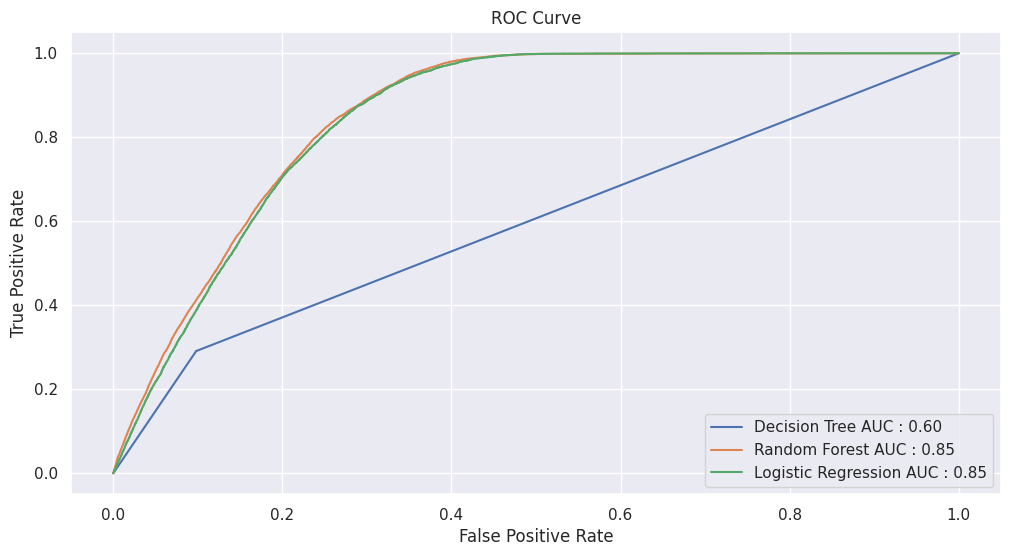

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

def plot_roc(ax,
        datase_train,
        dataset_test,
        model,
        title
):
    x_train, y_train = datase_train
    x_test,  y_test  = dataset_test

    y_test_prob = model.predict_proba(x_test)[:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_test_prob)

    auc = roc_auc_score(y_test, y_test_prob)
    ax.plot(fpr, tpr, label=f'{title} AUC : {auc:.2f}')

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)


def plot_precision_recall_curve(ax, 
                                dataset_train,
                                dataset_test,
                                model,
                                title : str):
    
    x_train, y_train = dataset_train
    x_test,  y_test  = dataset_test

    y_test_prob = model.predict_proba(x_test)[:,1]
    precision, recall, thresholds = precision_recall_curve(y_true = y_test,
    
                                                        probas_pred = y_test_prob)
    ax.plot(thresholds, precision[:-1], label=f'{title} - Precision')
    ax.plot(thresholds, recall[:-1], label=f'{title} - Recall')
    ax.set_title('Precision-Recall Curve')
    ax.set_xlabel('Thresholds')
    ax.set_ylabel('Precision/Recall')
    ax.legend(loc=0)

    return precision, recall, thresholds 


fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = model,
    title = 'Decision Tree'
)

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = logistic_model,
    title = 'Logistic Regression'
)
    

(array([0.1225592 , 0.12259271, 0.12259405, ..., 1.        , 1.        ,
        1.        ]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.78412132e-04, 8.92060660e-05, 0.00000000e+00]),
 array([0.00000000e+00, 5.98659004e-05, 6.45994832e-05, ...,
        8.27366391e-01, 8.32975306e-01, 8.34154334e-01]))

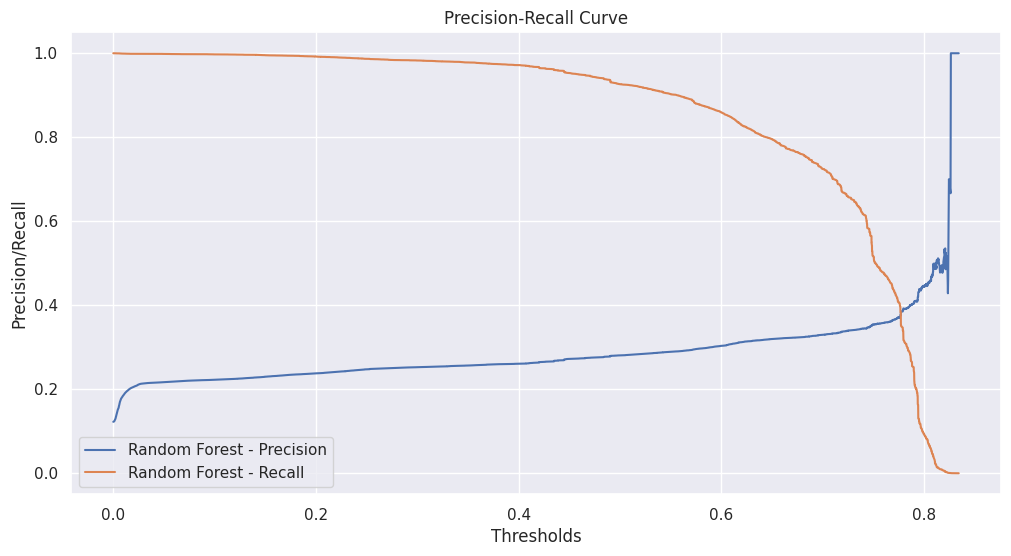

In [40]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)



(array([0.1225592 , 0.12256054, 0.12256188, ..., 0.        , 0.        ,
        1.        ]),
 array([1., 1., 1., ..., 0., 0., 0.]),
 array([7.38153024e-04, 8.80607555e-04, 1.03514687e-03, ...,
        9.18761372e-01, 9.22064779e-01, 9.35230230e-01]))

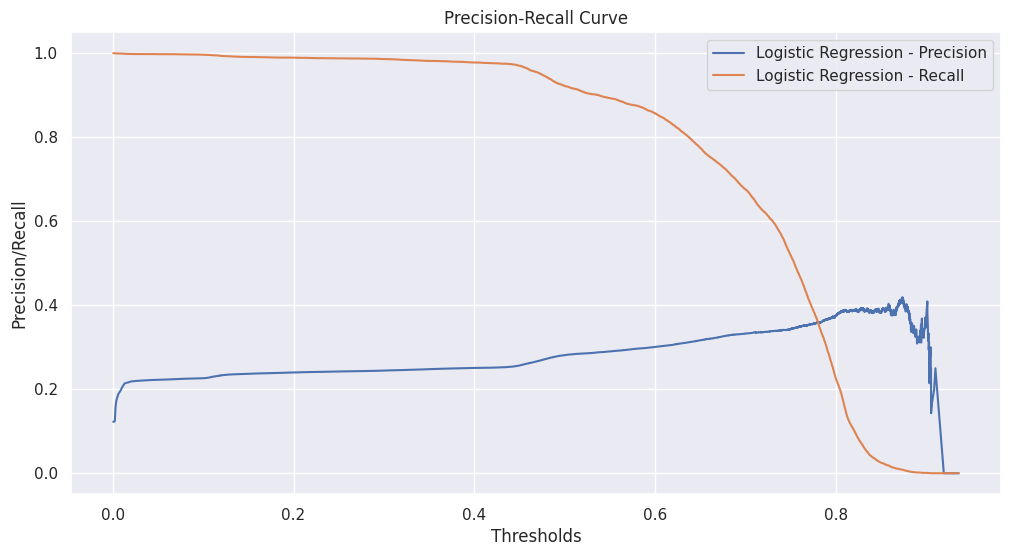

In [41]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = logistic_model,
    title = 'Logistic Regression'
)

**Overfitting com random over sample**

##### 3.3.1.2 - SMOTE

In [42]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

Response
0    200639
1    200639
Name: count, dtype: int64

In [43]:
rf_normal = RandomForestClassifier(criterion='entropy',
                            n_estimators=26,
                            max_depth=32,
                            n_jobs=-1)
rf_normal.fit(X = X_train,
          y = y_train)

RandomForestClassifier(criterion='entropy', max_depth=32, n_estimators=26,
                       n_jobs=-1)

In [44]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators=26,
                            max_depth=16,
                            n_jobs=-1)
rf.fit(X = X_train_smote,
          y = y_train_smote)


RandomForestClassifier(criterion='entropy', max_depth=16, n_estimators=26,
                       n_jobs=-1)

In [45]:
metrics_rf = du.computeMetricsSklearnModel(model = rf_normal,
                              dataset_train = (X_train, y_train),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'
metrics_rf

,accuracy,precision,recall,f1_score,auc,model
train,0.989837,0.998990,0.918005,0.956787,None,Random Forest
test,0.866388,0.364659,0.121499,0.182268,None,Random Forest
valid,0.866230,0.363236,0.121354,0.181928,None,Random Forest


In [46]:
metrics_rf = du.computeMetricsSklearnModel(model = rf,
                              dataset_train = (X_train_smote, y_train_smote),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'
metrics_rf

,accuracy,precision,recall,f1_score,auc,model
train,0.865594,0.806667,0.961672,0.877376,None,Random Forest
test,0.762382,0.312740,0.783943,0.447113,None,Random Forest
valid,0.759651,0.311615,0.794755,0.447694,None,Random Forest


(array([0.1225592 , 0.14528351, 0.14626468, ..., 0.5       , 0.        ,
        1.        ]),
 array([1.00000000e+00, 9.98840321e-01, 9.98840321e-01, ...,
        8.92060660e-05, 0.00000000e+00, 0.00000000e+00]),
 array([0.00000000e+00, 4.03329892e-06, 1.12263685e-05, ...,
        9.88026354e-01, 9.88315684e-01, 9.90015880e-01]))

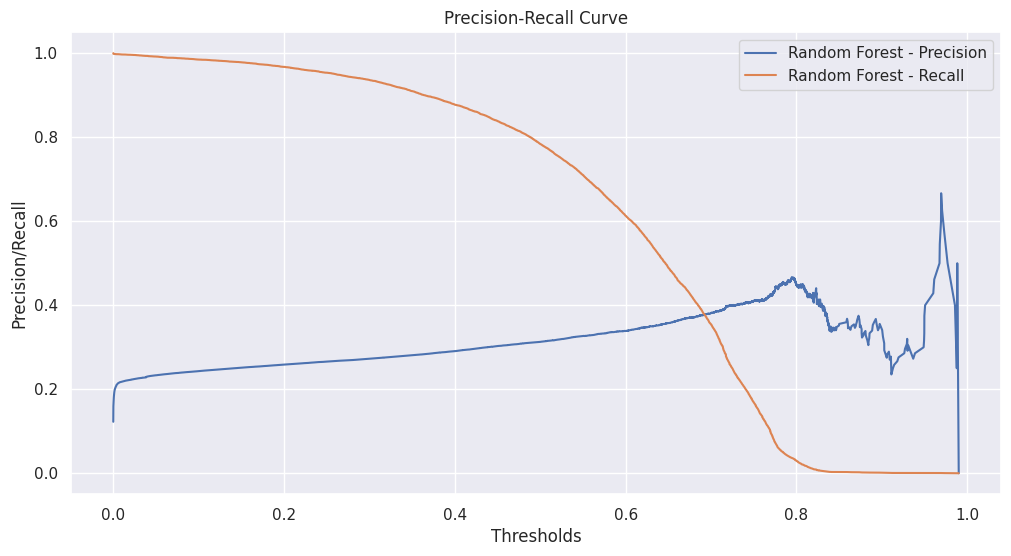

In [47]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_smote, y_train_smote),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)



#### 3.3.2 - UnderSampling

##### Random Under Sampling

**O Overfitting se mantem**

In [48]:
from imblearn.under_sampling import RandomUnderSampler
random_under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = random_under.fit_resample(X_train, y_train)
y_train_under.value_counts()

Response
0    28026
1    28026
Name: count, dtype: int64

In [49]:
def run_battery_test(
        curr_dataset_train,
        dataset_test,
        dataset_valid
):
        X_train, y_train = curr_dataset_train
        X_test,  y_test  = dataset_test
        X_valid, y_valid = dataset_valid

        rf_model = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_depth=48,
                                n_jobs=-1,
                                class_weight='balanced',
                                max_features='log2',
                                bootstrap=True
                                ,max_samples=0.8
                                )
        rf_model.fit(X = X_train,
                y = y_train)

        dt_model = DecisionTreeClassifier(criterion='gini',
                                max_depth=16)
        dt_model.fit(X = X_train,
                y = y_train)

        logistic_model = LogisticRegression(class_weight='balanced')
        logistic_model.fit(X = X_train,
                y = y_train) 

        metrics_rf = du.computeMetricsSklearnModel(model = rf_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))


        metrics_rf = pd.DataFrame(metrics_rf)
        metrics_rf['model'] = 'Random Forest'

        metrics_dt = du.computeMetricsSklearnModel(model = dt_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_dt = pd.DataFrame(metrics_dt)
        metrics_dt['model'] = 'Decision Tree'

        metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_lr = pd.DataFrame(metrics_lr)
        metrics_lr['model'] = 'Logistic Regression'

        metrics_all = pd.concat([metrics_rf, metrics_dt, metrics_lr], axis=0)
        metrics_all.sort_values(by=['f1_score'], ascending=False)

        return rf_model, dt_model, logistic_model, metrics_all




In [50]:
rf_normal, dt_normal, lr_normal, metrics_normal = run_battery_test(
    curr_dataset_train = (X_train, y_train),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_normal.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.998399,0.999386,0.987547,0.993431,None,Random Forest
valid,0.702352,0.282176,0.925207,0.432458,None,Logistic Regression
test,0.702644,0.281823,0.921142,0.431599,None,Logistic Regression
train,0.701734,0.281116,0.920574,0.430707,None,Logistic Regression
train,0.892537,0.766641,0.177121,0.287760,None,Decision Tree
test,0.869241,0.376156,0.101606,0.159994,None,Random Forest
valid,0.868461,0.363591,0.097538,0.153814,None,Random Forest
test,0.867699,0.331950,0.078501,0.126975,None,Decision Tree
valid,0.866444,0.309443,0.072786,0.117851,None,Decision Tree


(array([0.1225592 , 0.22331365, 0.22331813, ..., 0.        , 0.        ,
        1.        ]),
 array([1.        , 0.99170384, 0.99170384, ..., 0.        , 0.        ,
        0.        ]),
 array([0.        , 0.00466112, 0.00704696, ..., 0.85      , 0.89      ,
        0.94      ]))

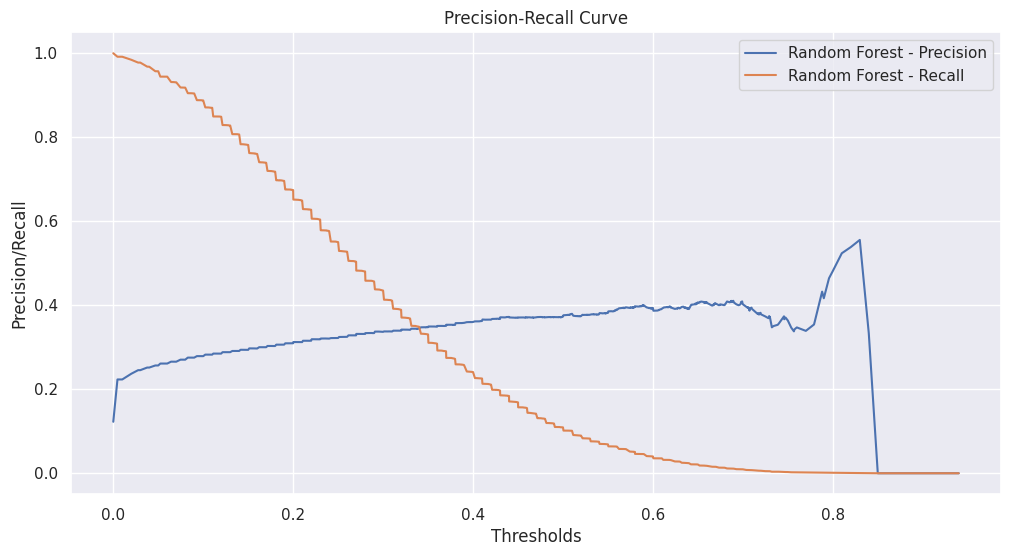

In [51]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train, y_train),
    dataset_test  = (X_test, y_test),
    model = rf_normal,
    title = 'Random Forest'
)



In [52]:
pd.DataFrame(zip([ x*-1 if x < 0 else x for x in lr_normal.coef_[0] ], X_train.columns), columns = ['feature_importance','feature_name']).sort_values(by='feature_importance', ascending=False)


,feature_importance,feature_name
7,5.209920,Policy_Sales_Channel
3,3.924776,Previously_Insured
2,2.847845,Region_Code
5,1.932001,Vehicle_Damage
6,1.063222,Annual_Premium
1,0.914825,Driving_License
9,0.908936,faixa_etaria
10,0.412908,entre_30_50
4,0.174526,Vehicle_Age
11,0.100762,sexo_feminino


In [53]:
pd.DataFrame(zip(rf_normal.feature_importances_, X_train.columns), columns = ['feature_importance','feature_name']).sort_values(by='feature_importance', ascending=False)

,feature_importance,feature_name
8,0.190179,Vintage
5,0.189767,Vehicle_Damage
6,0.165534,Annual_Premium
3,0.120841,Previously_Insured
7,0.092763,Policy_Sales_Channel
0,0.088914,Age
2,0.084125,Region_Code
9,0.025169,faixa_etaria
4,0.024403,Vehicle_Age
11,0.010507,sexo_feminino


In [54]:
rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under, y_train_under),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.998983,0.998681,0.999286,0.998983,None,Random Forest
train,0.860433,0.804143,0.952972,0.872255,None,Decision Tree
train,0.795583,0.737174,0.918718,0.817994,None,Logistic Regression
valid,0.703467,0.282676,0.923067,0.432811,None,Logistic Regression
test,0.704174,0.282714,0.919715,0.432485,None,Logistic Regression
test,0.713894,0.284471,0.880642,0.430031,None,Random Forest
valid,0.710929,0.283139,0.886808,0.429233,None,Random Forest
valid,0.701860,0.274135,0.869280,0.416822,None,Decision Tree
test,0.703015,0.273316,0.857984,0.414569,None,Decision Tree


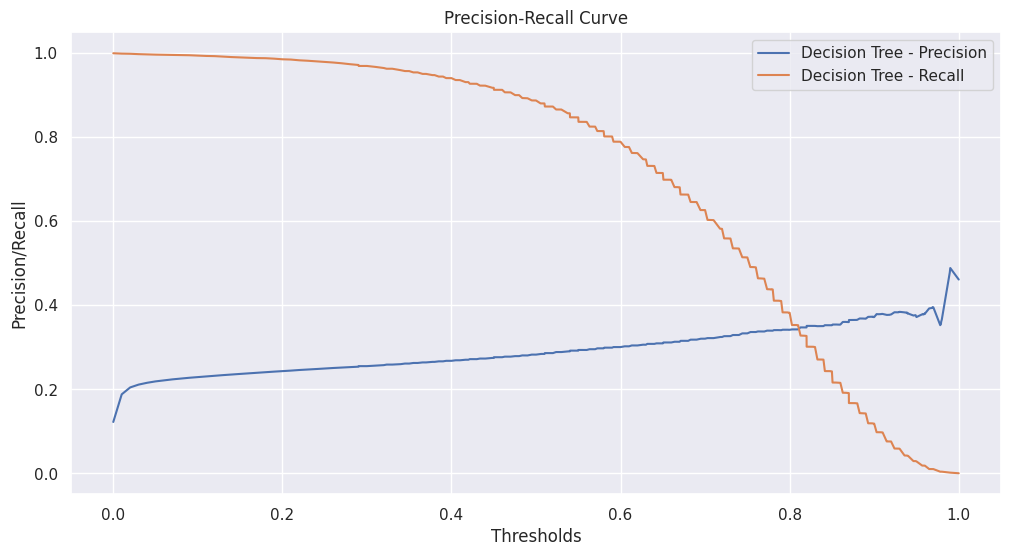

In [55]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

content = plot_precision_recall_curve(ax,
    dataset_train = (X_train_under, y_train_under),
    dataset_test  = (X_test, y_test),
    model = rf_under,
    title = 'Decision Tree'
)

**Teste reduzindo o numero de features**

In [56]:
importances = pd.DataFrame({'feature': X_train_under.columns, 'importance': lr_under.coef_[0]})
importances.importance = importances.importance.abs()
select_cols_lr = importances[importances.importance >= importances.importance.quantile(0.8)].feature.tolist()
len(select_cols_lr)


3

In [57]:
importances_rf = pd.DataFrame({'feature': X_train_under.columns, 'importance': dt_under.feature_importances_})
select_cols_rf = importances_rf[importances_rf.importance >= importances_rf.importance.quantile(0.75)].feature.tolist()
len(select_cols_rf)



3

**Logistic**

In [58]:
rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under.loc[:,select_cols_lr], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_lr], y_test),
    dataset_valid= (X_valid.loc[:,select_cols_lr], y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)


,accuracy,precision,recall,f1_score,auc,model
train,0.790605,0.723082,0.941947,0.818130,None,Random Forest
train,0.790034,0.723353,0.939306,0.817305,None,Decision Tree
train,0.777617,0.724151,0.896881,0.801313,None,Logistic Regression
valid,0.688625,0.269676,0.901793,0.415191,None,Logistic Regression
test,0.688573,0.268995,0.897235,0.413901,None,Logistic Regression
test,0.669615,0.261929,0.932828,0.409012,None,Decision Tree
test,0.668292,0.261317,0.934166,0.408392,None,Random Forest
valid,0.667782,0.261082,0.934573,0.408145,None,Decision Tree
valid,0.666306,0.260421,0.936179,0.407489,None,Random Forest


**Random Forest**

In [59]:


rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under.loc[:,select_cols_rf], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_rf], y_test),
    dataset_valid= (X_valid.loc[:,select_cols_rf], y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.811889,0.752791,0.928780,0.831576,None,Random Forest
train,0.799258,0.746199,0.907015,0.818785,None,Decision Tree
train,0.780971,0.731188,0.888639,0.802261,None,Logistic Regression
valid,0.700679,0.276890,0.894835,0.422916,None,Logistic Regression
test,0.700971,0.276261,0.888938,0.421522,None,Logistic Regression
test,0.691098,0.267616,0.875468,0.409924,None,Decision Tree
valid,0.689462,0.267070,0.879181,0.409689,None,Decision Tree
valid,0.677146,0.260087,0.885737,0.402102,None,Random Forest
test,0.678460,0.259844,0.878323,0.401043,None,Random Forest


**O Overfitting se mantem**

#### 3.3.3 - Undersampling com Tomek Link

In [60]:
from imblearn.under_sampling import TomekLinks 

tl = TomekLinks(sampling_strategy='majority') 
x_train_tomek, y_train_tomek = tl.fit_resample(X_train, y_train)
y_train_tomek.value_counts()

Response
0    189866
1     28026
Name: count, dtype: int64

In [61]:
rf_tomek, dt_tomek, lr_tomek, metrics_tomek = run_battery_test(
    curr_dataset_train = (x_train_tomek, y_train_tomek),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_tomek.sort_values(by=['f1_score'], ascending=False)


,accuracy,precision,recall,f1_score,auc,model
train,0.998843,0.999425,0.991579,0.995486,None,Random Forest
train,0.728714,0.312481,0.924142,0.467041,None,Logistic Regression
valid,0.699613,0.280675,0.928285,0.431025,None,Logistic Regression
test,0.699965,0.280451,0.924888,0.430395,None,Logistic Regression
train,0.892286,0.722809,0.263684,0.386405,None,Decision Tree
test,0.862419,0.371348,0.176896,0.239637,None,Random Forest
valid,0.861130,0.364282,0.178485,0.239583,None,Random Forest
test,0.860396,0.337163,0.143979,0.201788,None,Decision Tree
valid,0.859802,0.329311,0.138748,0.195237,None,Decision Tree


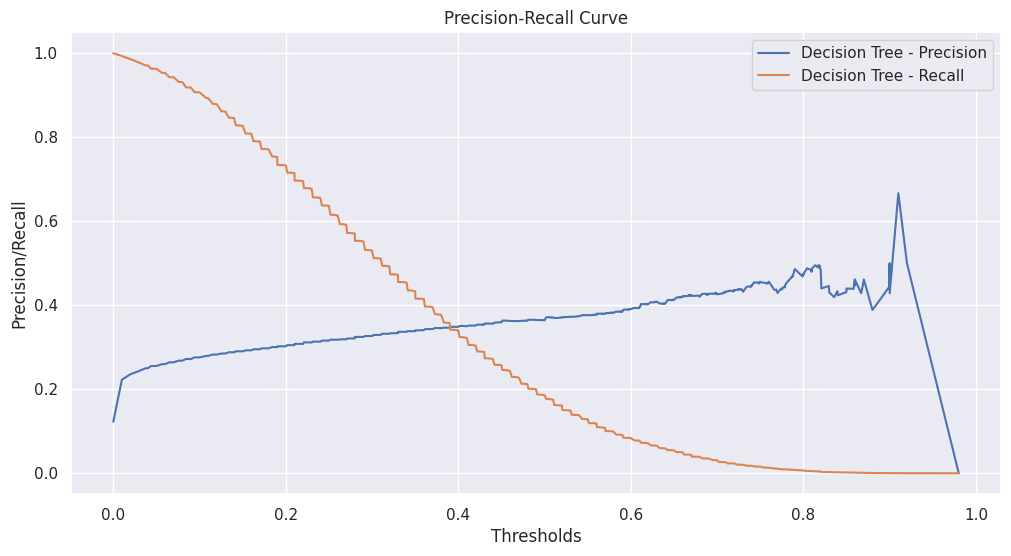

In [62]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

content = plot_precision_recall_curve(ax,
    dataset_train = (x_train_tomek, y_train_tomek),
    dataset_test  = (X_test, y_test),
    model = rf_tomek,
    title = 'Decision Tree'
)

#### 3.3.3 - Embeded model (estratégia propria) - Bonus (Ciclo 2)

A estratégia baseia-se em realizar diversos treinamentos, onde a cada novo treinamento havera um processo de amostratgem boostrap para a classe majoritaria e minoritaria, porém este processo sera realizado em um dataset equilibrado. 

**Exemplo:**

5k amostras classe 1 vs 100k amostras classe 2. 

* Cria-se um dateset, que recebe todas as amostras da classe 1, e uma amostragem aleatória da classe 2, contendo 5k elementos. 
* Realiza-se o treinamento com este subset (que pode receber 5k c1 e os 5k c2 ou, 3k c1 (amostragem por bootstrap) e 3kc2 (subamostragem por bootstrap)). 
* Cada contribui com a probabilidade do elemento pertecenter a uma das classes. 
* O resultado é dado pela média de probabilidades. 
    

# 4 - Treinamento dos modelos

**Ciclo 1:**
    
- KNN
- Logistic Regression 
- Random forest
- xGBoost
- Neural Networks

In [67]:
def get_top_k_metrics(df_metrics,
                      y_proba : np.array,
                      y_test : pd.Series,
                      set_of_data : str = '' ):
        

        df_metrics[f'dataset_abrangence_r80{set_of_data}']    = get_dataset_coverage(
                                                    up_to=0.8,
                                                    y_proba=y_proba,
                                                    y_test=y_test.values
                                                )
        
        df_metrics[f'dataset_abrangence_r100{set_of_data}']    = get_dataset_coverage(
                                                    up_to=1.0,
                                                    y_proba=y_proba,
                                                    y_test=y_test.values
                                                )
        df_metrics[f'precision_top_10{set_of_data}']          = precision_top_k(top_k=10, y_true=y_test.values, y_proba=y_proba)
        df_metrics[f'precision_top_100{set_of_data}']         = precision_top_k(top_k=100, y_true=y_test.values, y_proba=y_proba)
        df_metrics[f'precision_top_1000{set_of_data}']        = precision_top_k(top_k=1000, y_true=y_test.values, y_proba=y_proba)
        df_metrics[f'precision_top_20000{set_of_data}']       = precision_top_k(top_k=20000, y_true=y_test.values, y_proba=y_proba)

        return df_metrics

def run_model_training(
        curr_dataset_train,
        dataset_test,
        dataset_valid
):
        X_train, y_train = curr_dataset_train
        X_test,  y_test  = dataset_test
        X_valid, y_valid = dataset_valid

        # ------------------------------------------------------------
        print('Running Random Forest...')
        rf_model = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_depth=48,
                                n_jobs=-1,
                                class_weight='balanced',
                                max_features='log2',
                                bootstrap=True
                                ,max_samples=0.8
                                )
        rf_model.fit(X = X_train,
                y = y_train)
        metrics_rf = du.computeMetricsSklearnModel(model = rf_model,
                        dataset_train = (X_train, y_train),
                        dataset_test  = (X_test, y_test),
                        dataset_valid =  (X_valid, y_valid))
        metrics_rf = pd.DataFrame(metrics_rf)

        probas_rf = rf_model.predict_proba(X_test)[:,1]
        metrics_rf['model'] = 'Random Forest'
        metrics_rf = get_top_k_metrics(
                df_metrics=metrics_rf,
                y_proba=probas_rf,
                y_test=y_test
        )
        
        # ------------------------------------------------------------
        print('Running Logistic Regression...')
        logistic_model = LogisticRegression(class_weight='balanced')
        logistic_model.fit(
                           X = X_train,
                           y = y_train
                        ) 
        metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_lr = pd.DataFrame(metrics_lr)
        metrics_lr['model'] = 'Logistic Regression'

        probas_lr = logistic_model.predict_proba(X_test)[:,1]
        metrics_lr = get_top_k_metrics(
                df_metrics=metrics_lr,
                y_proba=probas_lr,
                y_test=y_test
        )

        # ------------------------------------------------------------
        print('Running KNN...')
        knn = KNeighborsClassifier(n_neighbors=5,
                                   n_jobs=-1)
        knn.fit(X = X_train, y = y_train)
        metrics_knn = du.computeMetricsSklearnModel(model = knn,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_knn = pd.DataFrame(metrics_knn)
        metrics_knn['model'] = 'KNN'

        probas_knn = knn.predict_proba(X_test)[:,1]
        metrics_knn = get_top_k_metrics(
                df_metrics=metrics_knn,
                y_proba=probas_knn,
                y_test=y_test
        )

        # --------------------------------------------------------------
        print('Running XGBoost...')
        xGboost = XGBClassifier(
                objective='binary:logistic',
                n_estimators=30,
                max_depth=6,
                learning_rate=0.1
        )

        xGboost.fit(X = X_train, y = y_train)
        metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_xgboost = pd.DataFrame(metrics_xgboost)
        metrics_xgboost['model'] = 'XGBoost'

        probas_xgboost = xGboost.predict_proba(X_test)[:,1]
        metrics_xgboost = get_top_k_metrics(
                df_metrics=metrics_xgboost,
                y_proba=probas_xgboost,
                y_test=y_test
        )


        metrics_all = pd.concat([metrics_rf, metrics_lr, metrics_xgboost, metrics_knn], axis=0)
        metrics_all.sort_values(by=['f1_score'], ascending=False)

        models = {
                'random_forest' : rf_model,
                'logistic_regression' : logistic_model,
                'xgboost' : xGboost,
                'knn' : knn
        }
        return models, metrics_all



In [ ]:
models, metrics_all = run_model_training(
      curr_dataset_train = (X_train_smote, y_train_smote),
        dataset_test = (X_test, y_test),
        dataset_valid = (X_valid, y_valid)
)

In [ ]:
metrics_all

,accuracy,precision,recall,f1_score,auc,model,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
train,0.999103,0.998541,0.999666,0.999103,None,Random Forest,0.341701,1.0,0.4,0.43,0.383,0.31425
test,0.835010,0.336286,0.355575,0.345662,None,Random Forest,0.341701,1.0,0.4,0.43,0.383,0.31425
valid,0.833825,0.331943,0.351351,0.341371,None,Random Forest,0.341701,1.0,0.4,0.43,0.383,0.31425
train,0.796206,0.736572,0.922243,0.819017,None,Logistic Regression,0.314707,1.0,0.4,0.35,0.378,0.33800
test,0.701878,0.281381,0.921855,0.431158,None,Logistic Regression,0.314707,1.0,0.4,0.35,0.378,0.33800
valid,0.701532,0.281708,0.926010,0.431996,None,Logistic Regression,0.314707,1.0,0.4,0.35,0.378,0.33800
train,0.825019,0.764667,0.939035,0.842928,None,XGBoost,0.312772,1.0,0.2,0.31,0.369,0.34510
test,0.731485,0.296717,0.869135,0.442401,None,XGBoost,0.312772,1.0,0.2,0.31,0.369,0.34510
valid,0.729706,0.296033,0.874632,0.442347,None,XGBoost,0.312772,1.0,0.2,0.31,0.369,0.34510
train,0.907122,0.848458,0.991298,0.914333,None,KNN,0.370772,1.0,0.3,0.29,0.330,0.28980


In [ ]:
# models_smote, metrics_all_smote = run_model_training(
#       curr_dataset_train = (X_train_smote, y_train_smote),
#         dataset_test = (X_test, y_test),
#         dataset_valid = (X_valid, y_valid)
# )

### Neural network

* Input (n_features)
* Hidden_1 (n_features * 4)
* Hidden_2 (2)

In [63]:
class NeuralNetworkModel(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetworkModel, self).__init__()
        self.input = nn.Linear(input_size, input_size*4)
        self.hidden1 = nn.Linear(input_size*4, input_size*2)
        self.output = nn.Linear(input_size*2, 1)

    def forward(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.hidden1(x)
        x = F.relu(x)
        x = self.output(x)
        x = F.sigmoid(x)
        return x

In [64]:
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1) 
train_tensor_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor  = torch.FloatTensor(X_test.values)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)

test_tensor_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [65]:

def get_test_loss(
        model, 
        test_dataset,
        criterion
):
    test_loss = []
    model.eval()
    with torch.no_grad():
        for data, target in test_dataset:
            output = model(data)
            loss = criterion(output, target)
            test_loss.append(loss.item())
    
    return np.mean(test_loss)

def train_neural_network(
        model, 
        train_dataset,
        test_dataset,
        optimizer,
        criterion,
        epochs : int = 10
):  
    train_loss = []
    train_loss_epoch = []
    test_loss_epoch = []
    for epoch in tqdm(range(0,epochs)):
        model.train()

        for data, target in train_dataset:
            optimizer.zero_grad()
            output = model(data)
            loss   = criterion(output, target)
            loss.backward()

            optimizer.step()

            train_loss.append(loss.item())
       
        train_loss_epoch.append(np.mean(train_loss))

        test_loss = get_test_loss(
            model=model,
            test_dataset=test_dataset,
            criterion=criterion
        )
        test_loss_epoch.append(test_loss)

        if epoch % 20 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
            print(f'Epoch {epoch}, Test Loss: {test_loss}')
            
    
    plt.plot(train_loss_epoch, label='Train Loss')
    plt.plot(test_loss_epoch, label='Test Loss')
    plt.legend()
    plt.show()

    return model, train_loss 

  2%|▏         | 1/60 [00:01<01:30,  1.54s/it]

Epoch 0, Loss: 0.5712658762931824
Epoch 0, Test Loss: 0.567230474948883


 35%|███▌      | 21/60 [00:32<01:06,  1.69s/it]

Epoch 20, Loss: 0.2931285798549652
Epoch 20, Test Loss: 0.27280789282586837


 68%|██████▊   | 41/60 [01:06<00:30,  1.61s/it]

Epoch 40, Loss: 0.27002131938934326
Epoch 40, Test Loss: 0.26927596728006997


100%|██████████| 60/60 [01:35<00:00,  1.60s/it]


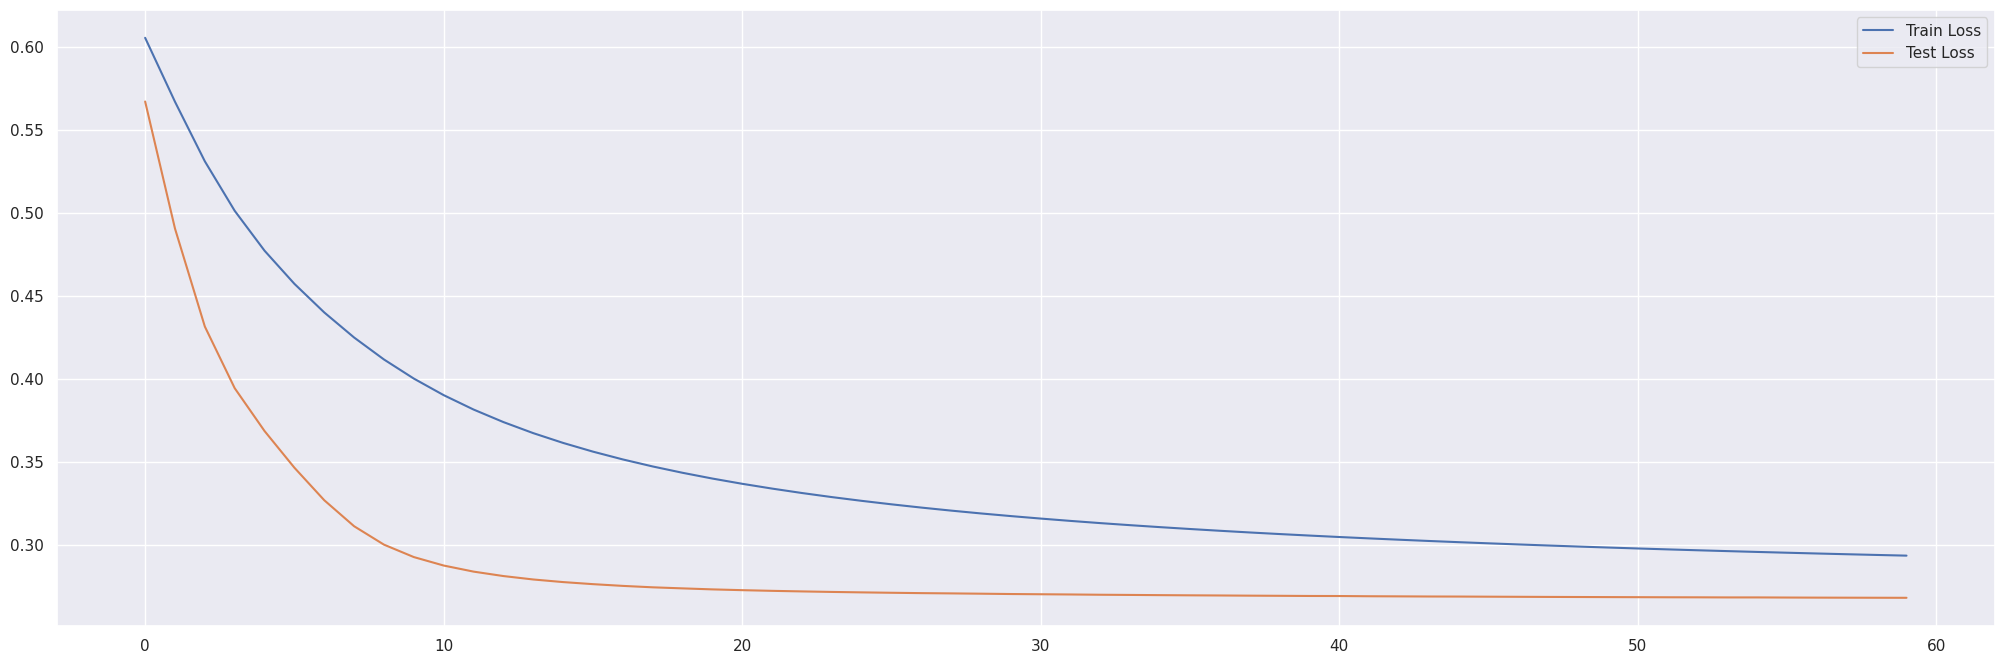

In [66]:
model = NeuralNetworkModel(input_size=X_train.shape[1])
criterion = nn.BCELoss() 
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=1e-4)



batch_size = 2056
train_dataloader = DataLoader(train_tensor_dataset,
                           batch_size=batch_size,
                           num_workers=4,
                           shuffle=True)

test_dataloader = DataLoader(test_tensor_dataset,
                            batch_size=batch_size,
                            num_workers=0,
                            shuffle=False)

model, train_loss = train_neural_network(
    model = model,
    train_dataset = train_dataloader,
    test_dataset= test_dataloader,
    optimizer = optimizer,
    criterion = criterion,
    epochs = 60
)

In [67]:
df_nn_metrics = get_top_k_metrics(pd.DataFrame({'model' : 'NeuralNetworkModel'},index=[0]),
                    y_proba  = model(X_test_tensor).detach().numpy().reshape(-1),
                    y_test = y_test)

metrics_all = pd.concat([metrics_all, df_nn_metrics], axis=0)
metrics_all.sort_values(by=['precision_top_20000'], ascending=False)

NameError: name 'get_top_k_metrics' is not defined

In [82]:
import random as rd
def plot_precision_top_k(y_proba, y_true, label : str, line_style='-'):
    precisions = []
    percentis = [x for x in range(1,100,10)]
    for i in percentis:
        precisions.append(precision_top_k(
            top_k = int((i/100)*len(y_proba)),
            y_true = y_true, 
            y_proba = y_proba
        ))
    
    df_results = pd.DataFrame(percentis, columns=['% Base'])
    df_results['Precision'] = precisions
    sns.lineplot(data = df_results,  x = '% Base', y = 'Precision', 
                 label=label, linestyle=line_style)
    plt.title('Precision vs % Base',fontdict={'fontsize': 24})

    return percentis, precisions 

def plot_recall_top_k(y_proba, 
                      y_true, 
                      label,
                      line_style='-'):
    
    recalls = []
    percentis = [x for x in range(1,100,10)]
    for i in percentis:
        recalls.append(recall_top_k(
            top_k = int((i/100)*len(y_proba)),
            y_true = y_true, 
            y_proba = y_proba
        ))
    
    df_results = pd.DataFrame(percentis, columns=['% Base'])
    df_results['Recall'] = recalls
    sns.lineplot(data = df_results,  x = '% Base', y = 'Recall', 
                 label=label, linestyle=line_style)
    
    plt.title('Recall vs % Base',
              fontdict={'fontsize': 24})
    
    return percentis, recalls 

In [ ]:
predictions_nn = model(X_test_tensor).detach().numpy().reshape(-1)
predictions_rf = models['random_forest'].predict_proba(X_test)[:,1]
predictions_xg = models['xgboost'].predict_proba(X_test)[:,1]
predictions_lr = models['logistic_regression'].predict_proba(X_test)[:,1]


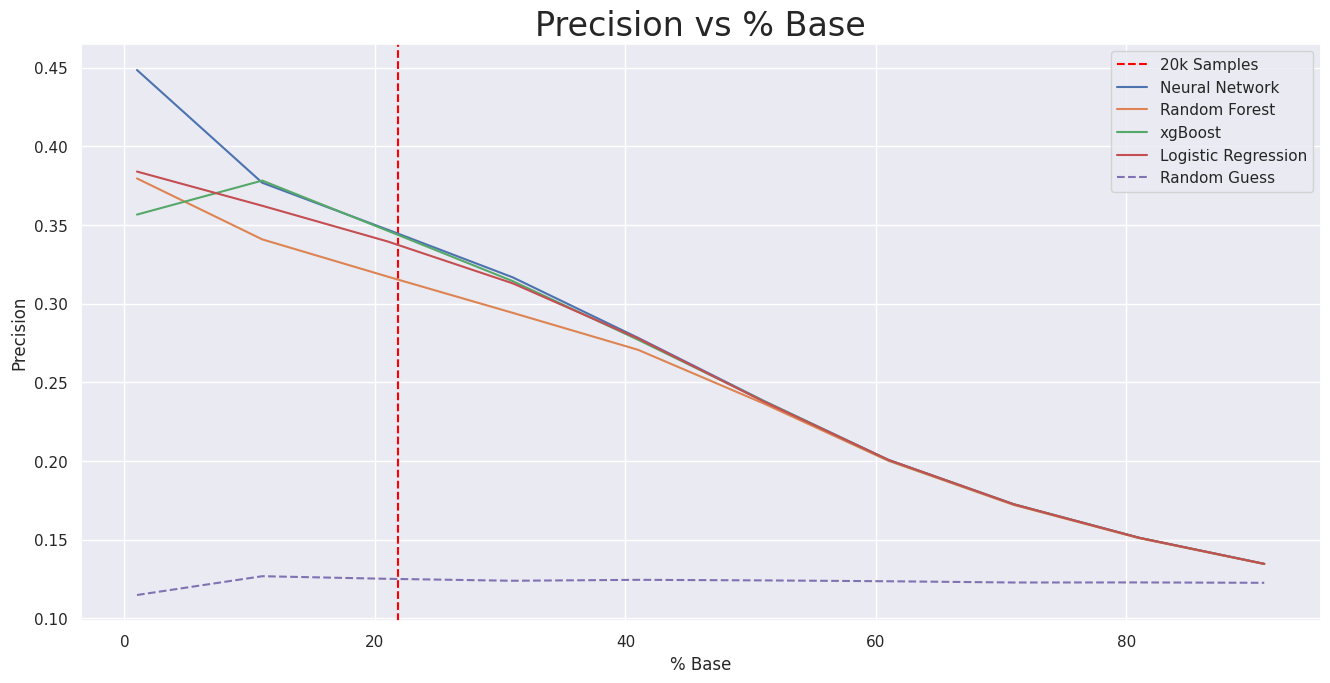

In [ ]:
plt.figure(figsize=(16,7.5))
plt.axvline(x=20e3/len(y_test)*100, color='red', linestyle='--', label='20k Samples')
percentis_nn, precisions_nn             =  plot_precision_top_k(y_proba=predictions_nn, y_true=y_test.values, label ='Neural Network')
percentis_rf, precisions_rf             =  plot_precision_top_k(y_proba=predictions_rf, y_true=y_test.values, label ='Random Forest')
percentis_xgboost, precisions_xgboost   =  plot_precision_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_lr, precisions_lr             =  plot_precision_top_k(y_proba=predictions_lr, y_true=y_test.values, label ='Logistic Regression')




In [ ]:
df_3.Annual_Premium.describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

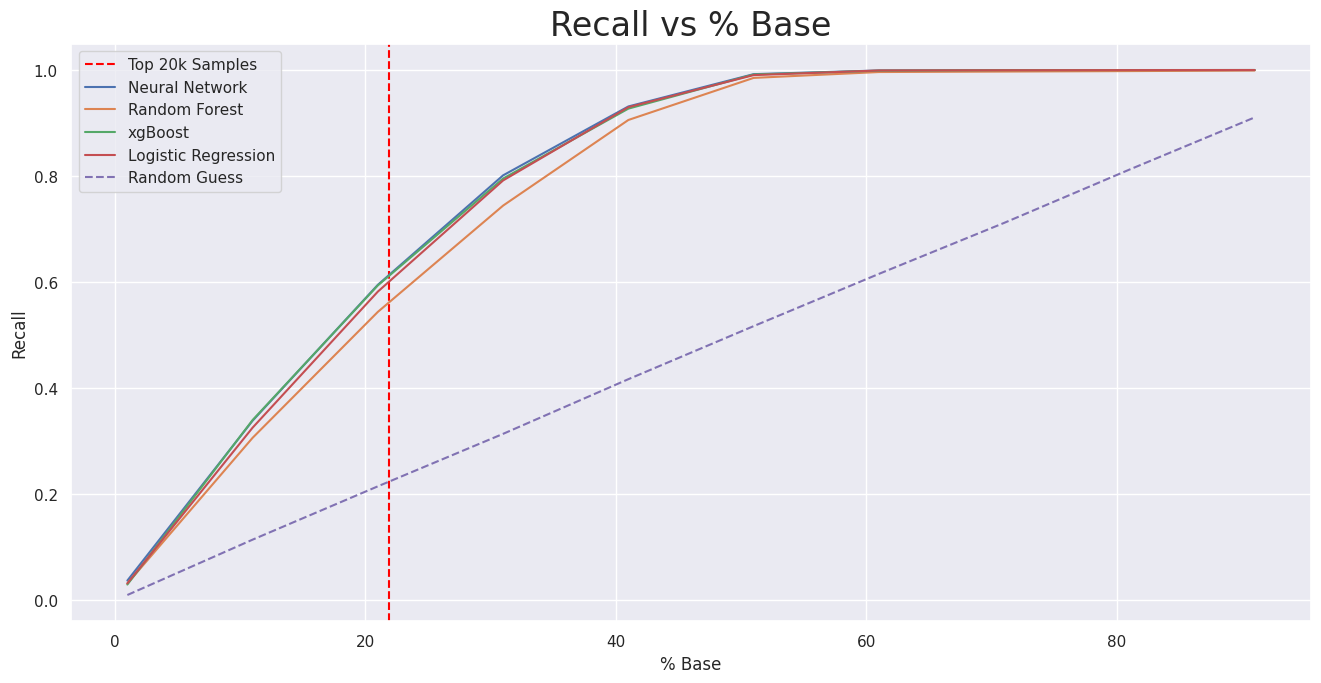

In [ ]:
plt.figure(figsize=(16,7.5))

plt.axvline(x=20e3/len(X_test)*100, color='red', linestyle='--', label='Top 20k Samples')
percentis_nn, recalls_nn =     plot_recall_top_k(y_proba=predictions_nn, y_true=y_test.values, label ='Neural Network')
percentis_rf, recalls_rf =     plot_recall_top_k(y_proba=predictions_rf, y_true=y_test.values, label ='Random Forest')
percentis_xgboost, recalls_xgboost =     plot_recall_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_lr, recalls_lr =     plot_recall_top_k(y_proba=predictions_lr, y_true=y_test.values, label ='Logistic Regression')


**Modelos elegíveis ao fine tuning:**
 * Redes Neurais
 * XGBosst

### 4.2 - Fine Tuning

#### 4.2.1 - XGboost

In [100]:
def train_xgboost(
        estimators      : int, 
        max_depth       : int, 
        learning_rate   : int,
        dataset_train   : list, 
        dataset_test    : list,
        dataset_valid   : list
):
    _x_train, _y_train              = dataset_train 
    _x_test, _y_test                = dataset_test
    _x_valid, _y_valid              = dataset_valid

    
    xGboost = XGBClassifier(
                    objective='binary:logistic',
                    n_estimators=estimators,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    n_jobs = -1
            )

    xGboost.fit(X = _x_train, y = _y_train)
    
    metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                            dataset_train = dataset_train,
                            dataset_test  = dataset_test,
                            dataset_valid =  dataset_valid)
    
    metrics_xgboost = pd.DataFrame(metrics_xgboost)
    metrics_xgboost['model'] = 'XGBoost'
    metrics_xgboost['parameters'] = f'n_estimators={estimators}, max_depth={depth}, learning_rate={lr}'

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(_x_train)[:,1],
                                        y_test=_y_train,
                                        set_of_data='_train')
    
    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(_x_test)[:,1],
                                        y_test=_y_test,
                                        set_of_data='_test')

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(_x_valid)[:,1],
                                        y_test=_y_valid,
                                        set_of_data='_valid')
    
    return metrics_xgboost

In [ ]:
lrs = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
n_estimators = [15,30, 45, 60, 80, 100, 120]
depths = [4, 6, 8, 10, 12]

metrics_xgboost_list = []
cont = 0
for depth in tqdm(depths):
    for estimators in n_estimators:
        for lr in lrs:
            print(f'Running {cont}/{len(depths) * len(n_estimators) * len(lrs)}: n_estimators={estimators}, max_depth={depth}, learning_rate={lr}')
            cont += 1
            xGboost = XGBClassifier(
                    objective='binary:logistic',
                    n_estimators=estimators,
                    max_depth=depth,
                    learning_rate=lr,
                    n_jobs = -1
            )

            xGboost.fit(X = X_train, y = y_train)
            metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                                    dataset_train = (X_train, y_train),
                                    dataset_test  = (X_test, y_test),
                                    dataset_valid =  (X_valid, y_valid))
            metrics_xgboost = pd.DataFrame(metrics_xgboost)
            metrics_xgboost['model'] = 'XGBoost'
            metrics_xgboost['parameters'] = f'n_estimators={estimators}, max_depth={depth}, learning_rate={lr}'

            metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                                y_proba=xGboost.predict_proba(X_test)[:,1],
                                                y_test=y_test)
            
            metrics_xgboost_list.append(metrics_xgboost)



    
    metrics_xgboost_list.append(metrics_xgboost)

In [108]:
xgBoostResults = pd.concat(metrics_xgboost_list).reset_index(drop = False)
xgBoostResults.rename(columns = {'index' : 'dataset'}, inplace = True)

**Best Test Parameters**

In [109]:
xgBoostResults[xgBoostResults.dataset == 'train'].sort_values(by=['precision_top_20000'], ascending=False).head(5)

,dataset,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
75,train,0.877944,0.654255,0.008778,0.017323,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.3",0.304802,1.0,0.5,0.53,0.481,0.35355
411,train,0.879383,0.769697,0.022658,0.044019,None,XGBoost,"n_estimators=100, max_depth=8, learning_rate=0.1",0.304692,1.0,0.7,0.51,0.447,0.35350
78,train,0.878158,0.629108,0.014344,0.028048,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.4",0.304310,1.0,0.6,0.53,0.487,0.35330
93,train,0.877917,0.737069,0.006101,0.012103,None,XGBoost,"n_estimators=80, max_depth=4, learning_rate=0.2",0.304113,1.0,0.7,0.46,0.493,0.35330
135,train,0.878272,0.718535,0.011204,0.022064,None,XGBoost,"n_estimators=120, max_depth=4, learning_rate=0.2",0.305042,1.0,0.5,0.52,0.498,0.35325


In [71]:
xgBoostResults[xgBoostResults.dataset == 'test'].sort_values(by=['precision_top_20000'], ascending=False).head(5)

,dataset,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
76,test,0.877495,0.516556,0.006958,0.013731,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.3",0.304802,1.0,0.5,0.53,0.481,0.35355
406,test,0.877419,0.496403,0.012310,0.024025,None,XGBoost,"n_estimators=100, max_depth=8, learning_rate=0.1",0.304692,1.0,0.7,0.51,0.447,0.35350
94,test,0.877419,0.487805,0.003568,0.007085,None,XGBoost,"n_estimators=80, max_depth=4, learning_rate=0.2",0.304113,1.0,0.7,0.46,0.493,0.35330
79,test,0.877353,0.484733,0.011329,0.022141,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.4",0.304310,1.0,0.6,0.53,0.487,0.35330
136,test,0.877441,0.500000,0.007761,0.015285,None,XGBoost,"n_estimators=120, max_depth=4, learning_rate=0.2",0.305042,1.0,0.5,0.52,0.498,0.35325


**Best parameters:**

* n_estimators=60, 
* max_depth=4, 
* learning_rate=0.3

#### 4.2.3 - Neural Network

In [73]:
from typing import Literal

class CustomNeuralNetworkModel(nn.Module):
    def __init__(self, 
                input_size,
                model_selected : Literal[1,2,3] = 1,
                out_1 : int = 64,
                out_2 : int = 32,
                out_3 : int = 1):
        
        super(CustomNeuralNetworkModel, self).__init__()
        self.input      = nn.Linear(input_size, out_1)
        self.hidden1    = nn.Linear(out_1, out_2)
        self.output     = nn.Linear(out_2, out_3)
        self.model_selected = model_selected
    
    
    def forward_1(self, x):
         x = self.forward_default(x) 
         return F.sigmoid(x) 
    
    def forward_2(self, x):
         x = self.forward_default(x) 
         return F.softmax(x) 
    
    def forward_default(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.hidden1(x)
        x = F.relu(x)
        x = self.output(x)
        
        return x
    
    def forward(self, x):
        if self.model_selected == 1:
            return self.forward_1(x)
        
        elif self.model_selected == 2:
            return self.forward_2(x)
    



In [ ]:
batch_sizes = [1028,2056,5112]

X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).reshape(-1,1).reshape(-1) 
train_tensor_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor  = torch.FloatTensor(X_test.values)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long).reshape(-1,1)

test_tensor_dataset = TensorDataset(X_test_tensor, y_test_tensor.reshape(-1))

train_dataloader = DataLoader(train_tensor_dataset,
                        batch_size=batch_size,
                        num_workers=4,
                        shuffle=True)

test_dataloader = DataLoader(test_tensor_dataset,
                            batch_size=batch_size,
                            num_workers=0,
                            shuffle=False)

In [ ]:

lower_network  = [16,8,2]
medium_network = [32,16,2]
higher_network = [128,64,2]
ballom_network = [16,64,2]
networks = [lower_network, medium_network, higher_network, ballom_network]  

lrs = [1e-4, 1e-3]
networks = [lower_network, medium_network, higher_network, ballom_network]  

# Definindo pessos inversamente proporcionais à frequência das classes
loss_weigths_balanced = torch.FloatTensor([1 - y_train.value_counts()[0] / len(y_train),               
                1 - y_train.value_counts()[1] / len(X_train)])

loss_weitghs_default = torch.FloatTensor([0.5, 0.5])


loss_weitghs_list = [loss_weigths_balanced, loss_weitghs_default]
networks = [lower_network, medium_network, higher_network]





In [119]:
y_train_tensor = y_train_tensor.reshape(-1).reshape(-1)
y_train_tensor.size()

torch.Size([228665])

In [136]:
def run_experiment_set_with_neural(model_path : str,
                               results_path : str,
                               architectures : list,
                               epochs_experiment : int = 10):

    metrics_nn_list = []
    batch_sizes = [1028,2056,5112]

    print('ahoyy')
    print(networks)
    for model_definition in tqdm(architectures):
        for loss_weigth in loss_weitghs_list:
            for lr in lrs:
                for batch_size in batch_sizes:

                    train_dataloader = DataLoader(train_tensor_dataset,
                                            batch_size=batch_size,
                                            num_workers=4,
                                            shuffle=True)

                    test_dataloader = DataLoader(test_tensor_dataset,
                                                batch_size=batch_size,
                                                num_workers=0,
                                                shuffle=False)
                    model_name = '_'.join([str(x) for x in model_definition]) + f'_lr_{lr}_batch_size_{batch_size}_weigth_{loss_weigth[-1]}'
                    
                    
                    print('-'*64)
                    print(f'Running model with architecture {model_definition} - loss weights {loss_weigth} - lr {lr} - batch_size {batch_size}')
                    print('-'*64)

                    out_1, out_2, out_3 = model_definition
                    model = CustomNeuralNetworkModel(
                                input_size=X_train.shape[1], 
                                model_selected=2,
                                out_1=out_1,
                                out_2=out_2, 
                                out_3=out_3
                            )
                    
                    criterion = nn.CrossEntropyLoss(weight=loss_weigth) 
                    #criterion = nn.BCELoss()
                    optimizer = torch.optim.Adam(model.parameters(), 
                                                lr=lr)



                    model, train_loss = train_neural_network(
                        model = model,
                        train_dataset = train_dataloader,
                        test_dataset= test_dataloader,
                        optimizer = optimizer,
                        criterion = criterion,
                        epochs = epochs_experiment
                    )

                    
                    metrics_nn = {}
                    metrics_nn['model'] = 'NeuralNetwork'
                    metrics_nn['parameters'] = f'model_layers={model_definition}, loss_weigth={loss_weigth.detach().numpy()}, learning_rate={lr}, batch_size={batch_size}'
                    #metrics_nn = pd.DataFrame(metrics_nn, index=[0])
                    print('Predicting test values...')
                    model.eval()
                    y_nn_proba = model(X_test_tensor)[:,1].detach().cpu().numpy()
                    metrics_nn = get_top_k_metrics(df_metrics=metrics_nn,
                                                        y_proba=y_nn_proba,
                                                        y_test=y_test)
                    
                    model_path_ = os.path.join(model_path, model_name) + '.pth'
                    torch.save(model.state_dict(),model_path_)
                    metrics_nn['train_loss'] = train_loss

                    print('Model experiment saved at: {model_path}')
                    metrics_nn['model_path'] = model_path_ 


                    with open(os.path.join(results_path, 
                                        model_name + '.json'), 'w') as f:
                        
                        json.dump(metrics_nn, f)

                    print('Results experiment saved at: {results_path}')

                    metrics_nn_list.append(metrics_nn)
            
        df_results = pd.DataFrame(metrics_nn_list)
        df_results.to_json(os.path.join(results_path, 'general_results.json'))
        
    return metrics_nn_list


In [ ]:
batch_sizes = [1028,2056,5112]

lower_network  = [16,8,2]
medium_network = [32,16,2]
higher_network = [128,64,2]
ballom_network = [16,64,2]
networks = [lower_network, medium_network, higher_network, ballom_network]  

run_experiment_set_with_neural(model_path = '../models/definition',
                           results_path= '../models/results',
                           epochs_experiment=60,
                           architectures=networks)

### 4.3 - Results 
**Champion model: XGboost, overcoming neural networks over all metrics**

* Compare neural network with xgboost using those metrics: 
    1. precision_top_20k_samples
    2. precision_top_1k_samples
    3. Dataset_Coverage_up_2_80%
    4. Overfiting bias




In [ ]:
df_list = []
for nm in tqdm(os.listdir('../models/results/')):
    if nm != 'general_results.json':
        fPath = os.path.join('../models/results/',nm)
        df_read = pd.read_json(fPath)
        df_read['fPath'] = fPath
        df_list.append(df_read)



In [113]:

nn_results = pd.concat(df_list)
nn_results = nn_results.drop(columns='train_loss')
nn_results = nn_results.drop_duplicates()
nn_results = nn_results.sort_values(by = 'precision_top_20000', ascending=False)
nn_results.head(3)


,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000,model_path,fPath
0,NeuralNetwork,"model_layers=[128, 64, 2], loss_weigth=[0.1225...",0.308246,1,0.2,0.40,0.380,0.34105,../models/definition/128_64_2_lr_0.001_batch_s...,../models/results/128_64_2_lr_0.001_batch_size...
0,NeuralNetwork,"model_layers=[16, 8, 2], loss_weigth=[0.122563...",0.309744,1,0.4,0.39,0.373,0.34085,../models/definition/16_8_2_lr_0.001_batch_siz...,../models/results/16_8_2_lr_0.001_batch_size_1...
0,NeuralNetwork,"model_layers=[32, 16, 2], loss_weigth=[0.12256...",0.311055,1,0.5,0.45,0.403,0.34040,../models/definition/32_16_2_lr_0.001_batch_si...,../models/results/32_16_2_lr_0.001_batch_size_...


In [117]:

xgBoostResults[xgBoostResults.dataset == 'test'].sort_values(by=['precision_top_20000'], ascending=False).head(3)

,dataset,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
76,test,0.877495,0.516556,0.006958,0.013731,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.3",0.304802,1.0,0.5,0.53,0.481,0.35355
406,test,0.877419,0.496403,0.012310,0.024025,None,XGBoost,"n_estimators=100, max_depth=8, learning_rate=0.1",0.304692,1.0,0.7,0.51,0.447,0.35350
94,test,0.877419,0.487805,0.003568,0.007085,None,XGBoost,"n_estimators=80, max_depth=4, learning_rate=0.2",0.304113,1.0,0.7,0.46,0.493,0.35330


In [118]:

xgBoostResults[xgBoostResults.dataset == 'valid'].sort_values(by=['precision_top_20000'], ascending=False).head(1)

,dataset,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
77,valid,0.877644,0.56701,0.007359,0.014529,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.3",0.304802,1.0,0.5,0.53,0.481,0.35355


### 4.3 - Cross Validation

In [ ]:
def train_xgboost(
        estimators      : int, 
        max_depth       : int, 
        learning_rate   : int,
        dataset_train   : list, 
        dataset_test    : list,
        dataset_valid   : list
):
    x_train, y_train              = dataset_train 
    x_test,  y_test               = dataset_test
    x_valid, y_valid              = dataset_valid

    
    xGboost = XGBClassifier(
                    objective='binary:logistic',
                    n_estimators=estimators,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    n_jobs = -1
            )

    xGboost.fit(X = x_train, y = y_train)
    
    metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                            dataset_train = dataset_train,
                            dataset_test  = dataset_test,
                            dataset_valid =  dataset_valid)
    
    metrics_xgboost = pd.DataFrame(metrics_xgboost)
    metrics_xgboost['model'] = 'XGBoost'
    metrics_xgboost['parameters'] = f'n_estimators={estimators}, max_depth={max_depth}, learning_rate={learning_rate}'

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(x_train)[:,1],
                                        y_test=y_train,
                                        set_of_data='_train')
    
    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(x_test)[:,1],
                                        y_test=y_test,
                                        set_of_data='_test')

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(x_valid)[:,1],
                                        y_test=y_valid,
                                        set_of_data='_valid')
    
    return metrics_xgboost

In [ ]:
def evaluate_model(
        model_name      : str, 
        sklearn_model,
        model_params    : dict,
        dataset_train   : tuple, 
        dataset_test    : tuple,
        dataset_valid   : tuple
):
    '''
    -- evaluate some skelarn model
    args:
        model_name    : str -> nome do modelo a ser utilizado
        skelarn_model : skelarn.model -> modelo do formato sklearn a ser testado
        model_params  : dict -> dicionario com os respectivos parametros do modelo
        dataset_train : tuple -> x, y
        dataset_test  : tuple -> x, y
        dataset_valid : tuple -> x, y

    returns:
        return model results
    '''
    x_train, y_train              = dataset_train 
    x_test,  y_test               = dataset_test
    x_valid, y_valid              = dataset_valid

    
    metrics_model = du.computeMetricsSklearnModel(model = sklearn_model,
                            dataset_train = dataset_train,
                            dataset_test  = dataset_test,
                            dataset_valid =  dataset_valid)
    
    metrics_model = pd.DataFrame(metrics_model)
    metrics_model['model'] = model_name
    metrics_model['parameters'] = model_params

    metrics_model = get_top_k_metrics(df_metrics=metrics_model,
                                        y_proba=model.predict_proba(x_train)[:,1],
                                        y_test=y_train,
                                        set_of_data='_train')
    
    metrics_model = get_top_k_metrics(df_metrics=metrics_model,
                                        y_proba=model.predict_proba(x_test)[:,1],
                                        y_test=y_test,
                                        set_of_data='_test')

    metrics_model = get_top_k_metrics(df_metrics=metrics_model,
                                        y_proba=model.predict_proba(x_valid)[:,1],
                                        y_test=y_valid,
                                        set_of_data='_valid')
    
    return metrics_model


def train_model(sklearn_model,
                model_params : dict, 
                model_name   : str,
                dataset_train : tuple, 
                dataset_test  : tuple,
                dataset_valid : tuple):
    
    '''
    returs:
        model trained, 
        results 
        
    train and evaluate some skelarn model
    '''
    model_evaluated = sklearn_model(**model_params)
    
    x_train, y_train = dataset_train
    
    model_evaluated.fit(x_train, y_train)

    results = evaluate_model(model_name=model_name, 
                      sklearn_model = model_evaluated, 
                      model_params  = model_params,
                      dataset_train = dataset_train,
                      dataset_test  = dataset_test,
                      dataset_valid = dataset_valid
                      )    
    
    return model_evaluated, results




def cross_validation(sklearn_model, 
                     dataset,
                     model_name : str = 'Default',
                     k_folds : int = 10,
                     model_params = dict
                     ):

    X, y = dataset
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = train_test_split(X, y, test_size=0.2, 
                                        random_state=42)


    k_fold = KFold(n_splits=k_folds)
    folds = k_fold.split(X_train_fold)
    results = []

    for train_idxs, test_idxs in tqdm(folds):
        x_train_current_fold = X_train_fold.iloc[train_idxs]
        y_train_current_fold = y_train_fold.iloc[train_idxs]

        x_test_current_fold = X_train_fold.iloc[test_idxs]
        y_test_current_fold = y_train_fold.iloc[test_idxs]


        _, isntance_results = train_model(
            sklearn_model=sklearn_model, 
            model_params=model_params, 
            model_name=model_name,
            dataset_train=(x_train_current_fold, y_train_current_fold),
            dataset_test=(x_test_current_fold, y_test_current_fold),
            dataset_valid=(X_test_fold, y_test_fold)

        )
      
        results.append(isntance_results)

    return results 
  



In [ ]:
n_estimators    = 60
max_depth       = 8
learning_rate   = 0.3

best_xGboost_params = {
           'objective'      : 'binary:logistic',
           'n_estimators'   : n_estimators,
           'max_depth'      : max_depth,
           'learning_rate'  : learning_rate,
           'n_jobs'         : -1
}






results_cross = cross_validation(sklearn_model=XGBClassifier,
                                dataset = (X,y),
                                model_name='MyModel',
                                model_params=best_xGboost_params)


10it [00:13,  1.34s/it]


In [122]:
df_resumo = df_r.groupby('dataset').agg(
    # Nome_da_Nova_Coluna = ('Coluna_Original', 'Função_de_Agregação')
    f1_mean=('f1_score', 'mean'),
    f1_std=('f1_score', 'std'),
    
    abrangence_r80_train_mean=('dataset_abrangence_r80_train', 'mean'),
    abrangence_r80_train_std=('dataset_abrangence_r80_train', 'std'),
    abrangence_r80_train_min=('dataset_abrangence_r80_train', 'min'),
    abrangence_r80_train_max=('dataset_abrangence_r80_train', 'max'),

    abrangence_r80_test_mean=('dataset_abrangence_r80_test', 'mean'),
    abrangence_r80_test_std=('dataset_abrangence_r80_test', 'std'),
    abrangence_r80_test_min=('dataset_abrangence_r80_test', 'min'),
    abrangence_r80_test_max=('dataset_abrangence_r80_test', 'max'),


    abrangence_r80_valid_mean=('dataset_abrangence_r80_valid', 'mean'),
    abrangence_r80_valid_std=('dataset_abrangence_r80_valid', 'std'),
    abrangence_r80_valid_min=('dataset_abrangence_r80_valid', 'min'),
    abrangence_r80_valid_max=('dataset_abrangence_r80_valid', 'max'),

    precision_20k_test_mean=('precision_top_20000_test', 'mean'),
    precision_20k_test_std=('precision_top_20000_test', 'std'),
    precision_20k_test_min=('precision_top_20000_test', 'min'),
    precision_20k_test_max=('precision_top_20000_test', 'max'),

    precision_20k_valid_mean=('precision_top_20000_valid', 'mean'),
    precision_20k_valid_std=('precision_top_20000_valid', 'std'),
    precision_20k_valid_min=('precision_top_20000_valid', 'min'),
    precision_20k_valid_max=('precision_top_20000_valid', 'max'),

    precision_20k_train_mean=('precision_top_20000_train', 'mean'),
    precision_20k_train_std=('precision_top_20000_train', 'std'),
    precision_20k_train_min=('precision_top_20000_train', 'min'),
    precision_20k_train_max=('precision_top_20000_train', 'max'),


).reset_index()
df_resumo

,dataset,f1_mean,f1_std,abrangence_r80_train_mean,abrangence_r80_train_std,abrangence_r80_train_min,abrangence_r80_train_max,abrangence_r80_test_mean,abrangence_r80_test_std,abrangence_r80_test_min,abrangence_r80_test_max,abrangence_r80_valid_mean,abrangence_r80_valid_std,abrangence_r80_valid_min,abrangence_r80_valid_max,precision_20k_test_mean,precision_20k_test_std,precision_20k_test_min,precision_20k_test_max,precision_20k_valid_mean,precision_20k_valid_std,precision_20k_valid_min,precision_20k_valid_max,precision_20k_train_mean,precision_20k_train_std,precision_20k_train_min,precision_20k_train_max
0,test,0.060603,0.006455,0.264392,0.001613,0.261851,0.265895,0.310525,0.00388,0.303134,0.315433,0.307073,0.001024,0.305752,0.308415,0.257971,0.003193,0.2541,0.2639,0.341236,0.001268,0.34,0.3435,0.532243,0.003886,0.5253,0.5373
1,train,0.122382,0.004472,0.264392,0.001613,0.261851,0.265895,0.310525,0.00388,0.303134,0.315433,0.307073,0.001024,0.305752,0.308415,0.257971,0.003193,0.2541,0.2639,0.341236,0.001268,0.34,0.3435,0.532243,0.003886,0.5253,0.5373
2,valid,0.062362,0.003697,0.264392,0.001613,0.261851,0.265895,0.310525,0.00388,0.303134,0.315433,0.307073,0.001024,0.305752,0.308415,0.257971,0.003193,0.2541,0.2639,0.341236,0.001268,0.34,0.3435,0.532243,0.003886,0.5253,0.5373


**Conclusions:**
    * The cross validation shows that the model has a stable behavior in some variaty of scenarios.Looking to abrangence_r80 metric, which  measure how much of my dataset in need to cover util reaching 80% of customers with intent to buy, the model follows both in train and valid ~ 31%. Which means that in dataset with 100 000 customers, and 20 000 with intent to buy, we need to reach out to 30 000 custumers to make 16 000 sales. 


**Obs:** The metric "precision_20k" in the test set is lower than train and valid set due to the sample test size. There aren't enough samples to reach the target of 20k customers with intent to buy 

# 5. - Results/Estimated return

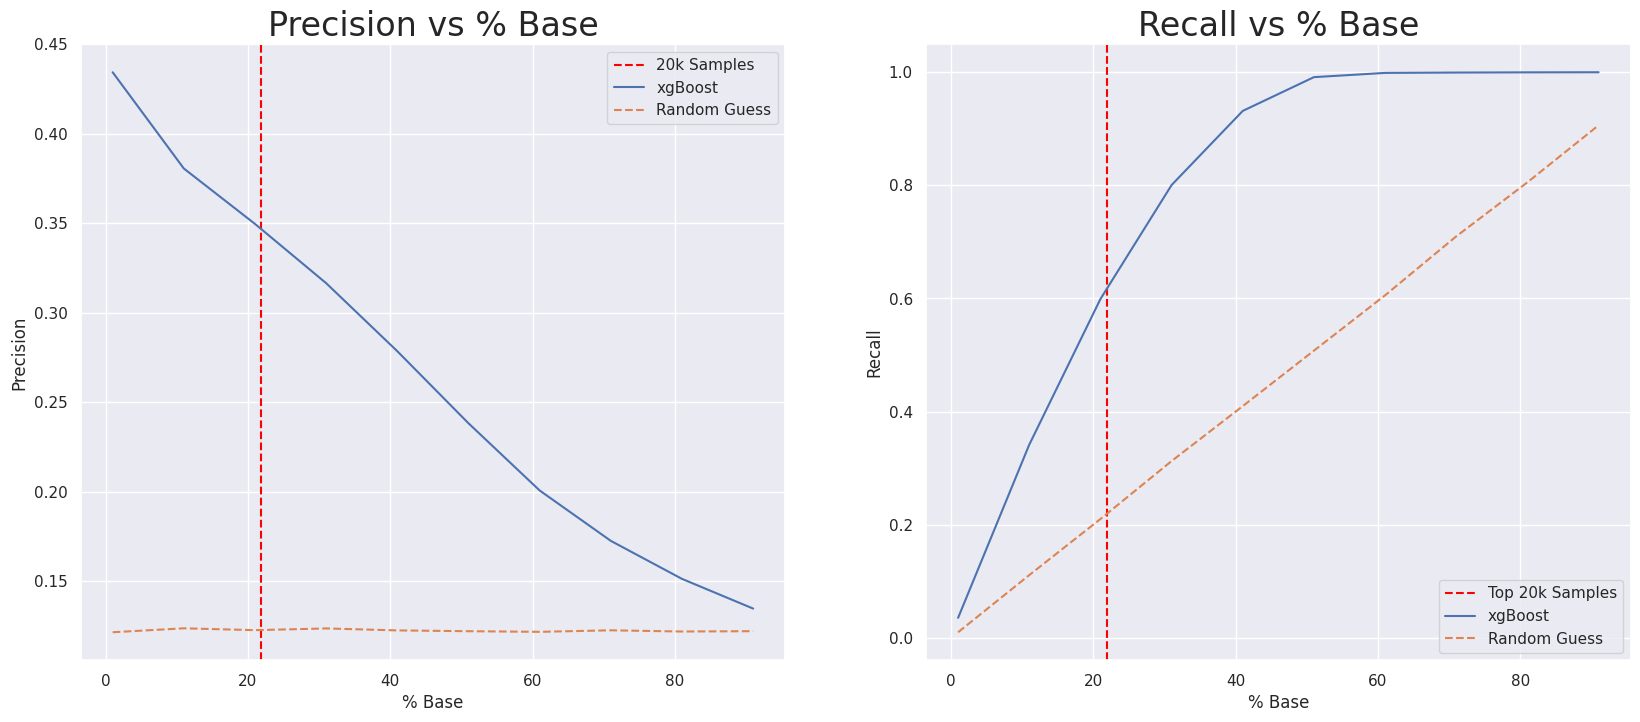

In [85]:
import random as rd 
best_xGboost ,results  = train_model(sklearn_model=XGBClassifier,
                           model_params=best_xGboost_params,
                           model_name='XGBOOST',
                           dataset_train=(X_train, y_train),
                           dataset_test=(X_test, y_test),
                           dataset_valid = (X_valid, y_valid))

rd.seed(43)

predictions_xg = best_xGboost.predict_proba(X_test)[:,1]
predictions_random = [rd.random() for x in range(len(X_test))]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,8))
plt.sca(ax1)
plt.axvline(x=20e3/len(y_test)*100, color='red', linestyle='--', label='20k Samples')
percentis_xgboost, precisions_xgboost   =  plot_precision_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_random, precisions_random     =  plot_precision_top_k(y_proba=predictions_random, y_true=y_test.values, label ='Random Guess', line_style='--')

plt.sca(ax2)
plt.axvline(x=20e3/len(X_test)*100, color='red', linestyle='--', label='Top 20k Samples')
percentis_xgboost, recalls_xgboost =     plot_recall_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_random, recalls_random = plot_recall_top_k(y_proba=predictions_random, y_true=y_test.values, label ='Random Guess', line_style='--')


### Simulations

In [88]:
df_3.Annual_Premium.describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64